In [2]:
import pandas as pd
import numpy as np
import os
from google.colab import drive

# 1. 구글 드라이브 마운트
drive.mount('/content/drive')

# 2. 데이터 파일 경로 설정
data_path = '/content/drive/MyDrive/epoch'

# 3. 데이터 로드
match_info = pd.read_csv(os.path.join(data_path, 'match_info.csv'))

train_df = pd.read_csv(os.path.join(data_path, 'train.csv'))



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import pandas as pd

# 1. 전체 피처(컬럼) 목록 및 데이터 타입, Non-Null 개수 확인
print("--- 1. 데이터 프레임 기본 정보 (info) ---")
train_df.info()

print("\n" + "="*50 + "\n")

# 2. 각 컬럼별 결측치(NaN) 개수 확인
print("--- 2. 컬럼별 결측치 개수 확인 ---")
print(train_df.isnull().sum())

print("\n" + "="*50 + "\n")

# 3. 실제 데이터가 어떻게 생겼는지 상위 5개 행 눈으로 확인
print("--- 3. 데이터 샘플 (상위 5개 행) ---")
display(train_df.head())

--- 1. 데이터 프레임 기본 정보 (info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356721 entries, 0 to 356720
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   game_id       356721 non-null  int64  
 1   period_id     356721 non-null  int64  
 2   episode_id    356721 non-null  int64  
 3   time_seconds  356721 non-null  float64
 4   team_id       356721 non-null  int64  
 5   player_id     356721 non-null  int64  
 6   action_id     356721 non-null  int64  
 7   type_name     356721 non-null  object 
 8   result_name   216467 non-null  object 
 9   start_x       356721 non-null  float64
 10  start_y       356721 non-null  float64
 11  end_x         356721 non-null  float64
 12  end_y         356721 non-null  float64
 13  is_home       356721 non-null  bool   
 14  game_episode  356721 non-null  object 
dtypes: bool(1), float64(5), int64(6), object(3)
memory usage: 38.4+ MB


--- 2. 컬럼별 결측치 개수 확인 ---
game_id   

,game_id,period_id,episode_id,time_seconds,team_id,player_id,action_id,type_name,result_name,start_x,start_y,end_x,end_y,is_home,game_episode
0,126283,1,1,0.667,2354,344559,0,Pass,Successful,52.418205,33.485444,31.322445,38.274752,True,126283_1
1,126283,1,1,3.667,2354,250036,2,Pass,Successful,32.013240,38.100808,37.371285,30.632980,True,126283_1
2,126283,1,1,4.968,2354,500145,4,Carry,NaN,37.371285,30.632980,38.391570,24.613144,True,126283_1
3,126283,1,1,8.200,2354,500145,5,Pass,Successful,38.391570,24.613144,34.573350,5.545468,True,126283_1
4,126283,1,1,11.633,2354,142106,7,Pass,Successful,34.578705,6.058256,21.274470,18.437112,True,126283_1


In [4]:
import pandas as pd
import numpy as np

df_eda = train_df.copy()

print("--- 1. 데이터 기본 구조 및 결측치 비율 확인 ---")
total_rows = len(df_eda)

# 각 컬럼별 결측치 개수와 비율 계산
missing_info = pd.DataFrame({
    'Missing_Count': df_eda.isnull().sum(),
    'Missing_Ratio(%)': (df_eda.isnull().sum() / total_rows) * 100
})

# 결측치가 하나라도 있는 컬럼만 필터링해서 내림차순 정렬
missing_info = missing_info[missing_info['Missing_Count'] > 0].sort_values(by='Missing_Count', ascending=False)

display(missing_info)
print(" 분석: result_name 컬럼에 약 14%의 결측치가 존재하며, player_id에도 소수의 결측치가 보입니다.")

--- 1. 데이터 기본 구조 및 결측치 비율 확인 ---


,Missing_Count,Missing_Ratio(%)
result_name,140254,39.317562


 분석: result_name 컬럼에 약 14%의 결측치가 존재하며, player_id에도 소수의 결측치가 보입니다.


In [5]:
print("--- 2. 범주형 변수 심층 분석 (결측치의 원인 찾기) ---")

# result_name이 결측치(NaN)인 데이터만 따로 뽑아봅니다.
missing_result_df = df_eda[df_eda['result_name'].isnull()]

print("result_name이 비어있는 이벤트 종류 Top 5:")
display(missing_result_df['type_name'].value_counts().head(5))

print("\ 분석 결론: 결측치의 대부분이 'Carry(드리블 이동)', 'Clearance(걷어내기)' 등에서 발생했습니다.")
print("이는 데이터 누락 오류가 아니라, 축구 기록 특성상 '성공/실패'를 명확히 나눌 수 없는 이동성 액션이기 때문입니다.")
print("▶ 전처리 전략: 삭제하지 않고 'None_Action' 등의 새로운 범주로 채워넣어야 합니다!")

--- 2. 범주형 변수 심층 분석 (결측치의 원인 찾기) ---
📌 result_name이 비어있는 이벤트 종류 Top 5:


,count
type_name,
Carry,82046
Recovery,27352
Interception,11088
Clearance,6563
Intervention,6038



💡 분석 결론: 결측치의 대부분이 'Carry(드리블 이동)', 'Clearance(걷어내기)' 등에서 발생했습니다.
이는 데이터 누락 오류가 아니라, 축구 기록 특성상 '성공/실패'를 명확히 나눌 수 없는 이동성 액션이기 때문입니다.
▶️ 전처리 전략: 삭제하지 않고 'None_Action' 등의 새로운 범주로 채워넣어야 합니다!


# TASK 1: 도메인 지식 기반의 논리적 이상치(Logical Outlier) 탐색

단순한 좌표 범위 이탈 외에도, 축구 경기의 물리적/시간적 흐름에 위배되는 논리적 이상치가 존재하는지 검증합니다.

1. **시간 역전 현상 (Time Reversal):**
동일한 플레이 시퀀스(`game_episode`) 내에서, 다음 액션의 발생 시간이 이전 액션보다 과거로 기록된 시계열 로깅 오류가 있는지 확인합니다.

2. **제자리 패스 (Zero-Distance Pass):**
패스(Pass) 이벤트임에도 불구하고 시작 좌표(`start_x`, `start_y`)와 종료 좌표(`end_x`, `end_y`)가 완벽하게 동일한 데이터가 있는지 확인합니다. 패스는 본질적으로 공간의 이동을 수반하므로, 이동 거리가 0인 패스는 센서 기록 누락이거나 잘못 분류된 데이터일 확률이 높습니다.

3. **자기 진영 깊은 곳에서의 슈팅 (Misclassified Shot):**
슈팅(Shot)은 일반적으로 상대 골문(X=105) 근처에서 발생합니다. 만약 우리 팀 페널티 박스 근처(예: X < 30)에서 슈팅이 기록되었다면, 이는 슈팅이 아니라 길게 걷어낸 'Clearance'가 잘못 기록되었을(Mislabeling) 가능성이 큽니다.

In [15]:
import pandas as pd
import numpy as np

# 원본 데이터 보호
df_logical = train_df.copy()

print("--- 1. 시간 역전 현상 (Time Reversal) 확인 ---")
# 에피소드와 액션 순서대로 정렬
df_logical = df_logical.sort_values(by=['game_episode', 'action_id'])

# 같은 에피소드 내에서 이전 액션과의 시간 차이 계산
df_logical['time_diff'] = df_logical.groupby('game_episode')['time_seconds'].diff()

# 시간이 거꾸로 흘러간(음수인) 데이터 필터링
time_errors = df_logical[df_logical['time_diff'] < 0]
print(f"시간이 역전된 기록 개수: {len(time_errors)}개")
if len(time_errors) > 0:
    display(time_errors[['game_episode', 'action_id', 'type_name', 'time_seconds', 'time_diff']].head(3))

print("\n--- 2. 제자리 패스 (Zero-Distance Pass) 확인 ---")
# 패스인데 시작점과 도착점이 완전히 같은 경우
zero_passes = df_logical[(df_logical['type_name'] == 'Pass') &
                         (df_logical['start_x'] == df_logical['end_x']) &
                         (df_logical['start_y'] == df_logical['end_y'])]
print(f"이동 거리가 0인 제자리 패스 개수: {len(zero_passes)}개")

print("\n--- 3. 비상식적인 위치에서의 슈팅 (Misclassified Shot) 확인 ---")
# 슈팅인데 X좌표가 중앙선(52.5) 이전, 특히 30 미만인 경우
weird_shots = df_logical[(df_logical['type_name'] == 'Shot') & (df_logical['start_x'] < 30)]
print(f"자기 진영 깊은 곳(X < 30)에서 기록된 슈팅 개수: {len(weird_shots)}개")
if len(weird_shots) > 0:
    display(weird_shots[['game_episode', 'type_name', 'start_x', 'start_y']].head(3))

--- 1. 시간 역전 현상 (Time Reversal) 확인 ---
시간이 역전된 기록 개수: 297개


,game_episode,action_id,type_name,time_seconds,time_diff
339,126283_11,547,Tackle,860.667,-0.001
1230,126283_47,1965,Tackle,619.207,-0.026
2073,126284_5,148,Tackle,305.900,-0.033



--- 2. 제자리 패스 (Zero-Distance Pass) 확인 ---
이동 거리가 0인 제자리 패스 개수: 7개

--- 3. 비상식적인 위치에서의 슈팅 (Misclassified Shot) 확인 ---
자기 진영 깊은 곳(X < 30)에서 기록된 슈팅 개수: 1개


,game_episode,type_name,start_x,start_y
274251,126432_82,Shot,19.320945,51.032912


In [18]:

# 1. 삭제 전 데이터 크기 확인
print(f"이상치 삭제 전 데이터 크기: {len(df_logical)}행")

# 2. 이상치 인덱스 모으기
# 앞서 찾은 이상치들의 인덱스(행 번호)를 리스트로 추출합니다.
indices_to_drop = list(time_errors.index) + list(zero_passes.index) + list(weird_shots.index)

# 중복된 인덱스가 있을 수 있으니 고유값(set)으로 변환 후 삭제 진행
df_cleaned = df_logical.drop(index=set(indices_to_drop))

# 3. 삭제 후 데이터 크기 확인
print(f"이상치 삭제 후 데이터 크기: {len(df_cleaned)}행")
print(f"총 {len(df_logical) - len(df_cleaned)}개의 논리적 이상치(노이즈)가 성공적으로 제거되었습니다!")


이상치 삭제 전 데이터 크기: 356721행
이상치 삭제 후 데이터 크기: 356416행
총 305개의 논리적 이상치(노이즈)가 성공적으로 제거되었습니다!


# TASK 1: 데이터 결측치 최종 정제 (Missing Value Imputation & Drop)

피처 엔지니어링을 수행하기 전, 데이터셋에 존재하는 결측치를 각 변수의 특성에 맞게 처리하여 데이터의 무결성을 확보합니다.

### 1. 결측치 처리 전략
* **result_name (이벤트 결과):** Carry(드리블), Clearance(걷어내기) 등 성공/실패 구분이 적용되지 않는 액션에서 주로 결측치가 발생합니다. 이를 삭제하면 경기 흐름이 끊기므로 'Not_Applicable'이라는 새로운 범주로 대체하여 데이터를 보존합니다.
* **player_id (선수 식별자):** 선수를 특정할 수 없는 누락 데이터는 분석 및 예측의 정확도를 떨어뜨리는 노이즈로 간주하여 해당 행(Row)을 모두 삭제합니다.
* **end_x, end_y (종료 좌표):** 가로채기나 태클 등 공간 이동을 수반하지 않는 제자리 액션의 경우 종료 좌표가 기록되지 않습니다. 이는 논리적으로 시작 좌표 위치에서 액션이 끝난 것을 의미하므로, 결측치를 시작 좌표(start_x, start_y) 값으로 복사하여 대체합니다.

In [19]:
import pandas as pd
import numpy as np

# 앞서 이상치를 제거한 데이터프레임(df_cleaned)을 복사하여 사용합니다.
df_model = df_cleaned.copy()

print("--- 1. 전처리 전 컬럼별 결측치 개수 ---")
missing_counts = df_model.isnull().sum()
print(missing_counts[missing_counts > 0])

# ----------------------------------------------------
# [전처리 1] result_name: 성공/실패 여부가 없는 액션 처리
# ----------------------------------------------------
df_model['result_name'] = df_model['result_name'].fillna('Not_Applicable')

# ----------------------------------------------------
# [전처리 2] player_id: 선수가 기록되지 않은 불확실한 데이터 삭제
# ----------------------------------------------------
df_model = df_model.dropna(subset=['player_id'])

# ----------------------------------------------------
# [전처리 3] end_x, end_y: 이동이 없는 액션의 종료 좌표 논리적 대체
# ----------------------------------------------------
# 종료 좌표가 누락된 행에 대해, 해당 액션의 시작 좌표를 덮어씌웁니다.
df_model['end_x'] = df_model['end_x'].fillna(df_model['start_x'])
df_model['end_y'] = df_model['end_y'].fillna(df_model['start_y'])


print("\n--- 2. 전처리 완료 후 컬럼별 결측치 재확인 ---")
print(df_model.isnull().sum())

# 최종 데이터 크기 확인
print(f"\n최종 정제가 완료된 데이터 크기: {len(df_model)}행")

--- 1. 전처리 전 컬럼별 결측치 개수 ---
result_name    140216
time_diff       15435
dtype: int64

--- 2. 전처리 완료 후 컬럼별 결측치 재확인 ---
game_id             0
period_id           0
episode_id          0
time_seconds        0
team_id             0
player_id           0
action_id           0
type_name           0
result_name         0
start_x             0
start_y             0
end_x               0
end_y               0
is_home             0
game_episode        0
time_diff       15435
dtype: int64

최종 정제가 완료된 데이터 크기: 356416행


In [20]:
# 이상치 탐색용으로 사용했던 임시 컬럼(time_diff) 삭제
df_model = df_model.drop(columns=['time_diff'])

print("--- 최종 결측치 재확인 ---")
print(df_model.isnull().sum())
print("\n최종 데이터 크기:", df_model.shape)

--- 최종 결측치 재확인 ---
game_id         0
period_id       0
episode_id      0
time_seconds    0
team_id         0
player_id       0
action_id       0
type_name       0
result_name     0
start_x         0
start_y         0
end_x           0
end_y           0
is_home         0
game_episode    0
dtype: int64

최종 데이터 크기: (356416, 15)


# TASK 2: 피처 엔지니어링 (Feature Engineering)

본 과제의 목표는 특정 액션의 시작 좌표(`start_x`, `start_y`)와 상황 정보를 바탕으로, 공의 도착 좌표(`end_x`, `end_y`)를 예측하는 것입니다. 예측 모델의 성능을 높이기 위해 도메인 지식을 활용하여 2가지 파생 변수를 생성합니다.

### 파생 변수 1: 경기장 구역 분할 (`pitch_zone`)
* **아이디어:** X좌표와 Y좌표를 연속된 숫자로만 두지 않고, 축구 전술 단위인 9분할 구역(Defensive/Mid/Attacking x Left/Center/Right)으로 범주화합니다.
* **이유:** 선수가 '수비 진영 중앙'에 있는지, '공격 진영 측면'에 있는지에 따라 빌드업 패스를 할지, 크로스를 올릴지 패턴이 완전히 달라지므로 모델에게 공간적 맥락을 제공합니다.

### 파생 변수 2: 직전 액션 정보 (`prev_action`) - 빌드업 맥락
* **아이디어:** 같은 공격 흐름(`game_episode`) 내에서 방금 전에 어떤 액션이 있었는지(예: 가로채기 직후인가? 짧은 패스 직후인가?)를 가져와 새로운 컬럼으로 만듭니다.
* **이유:** 도착 좌표는 현재 액션뿐만 아니라 "어떤 상황에서 이어받았는가"에 크게 의존합니다. 역습 상황인지, 지공(빌드업) 상황인지를 모델이 추론할 수 있게 하는 강력한 시계열 힌트입니다.

In [21]:
# df_model이 준비되어 있다고 가정하고 진행합니다.

# ----------------------------------------------------
# 파생 변수 1: 경기장 구역 분할 (Pitch Zone)
# ----------------------------------------------------
# X좌표 기준 (수비, 미드필드, 공격 지역)
def get_x_zone(x):
    if x < 35:
        return 'Defensive'
    elif x < 70:
        return 'Midfield'
    else:
        return 'Attacking'

# Y좌표 기준 (우측, 중앙, 좌측) - Y축은 0~68
def get_y_zone(y):
    if y < 20:
        return 'Right'
    elif y > 48:
        return 'Left'
    else:
        return 'Center'

# apply 함수를 사용하여 새로운 컬럼 생성 후 두 글자를 결합
df_model['zone_x'] = df_model['start_x'].apply(get_x_zone)
df_model['zone_y'] = df_model['start_y'].apply(get_y_zone)
df_model['pitch_zone'] = df_model['zone_x'] + "_" + df_model['zone_y']

# 임시 생성한 분할 컬럼은 삭제하여 데이터프레임 정리
df_model = df_model.drop(columns=['zone_x', 'zone_y'])

# ----------------------------------------------------
# 파생 변수 2: 직전 액션 정보 (Previous Action) - 빌드업 맥락
# ----------------------------------------------------
# 시계열 순서대로 데이터가 정렬되어 있는지 확실히 하기 위해 정렬
df_model = df_model.sort_values(by=['game_episode', 'action_id'])

# 같은 에피소드 내에서 바로 위 행(shift)의 이벤트 종류(type_name)를 가져옴
df_model['prev_action'] = df_model.groupby('game_episode')['type_name'].shift(1)

# 에피소드의 첫 번째 액션이라 이전 액션이 없는 경우 'First_Action'으로 채움
df_model['prev_action'] = df_model['prev_action'].fillna('First_Action')

# ----------------------------------------------------
# 최종 확인
# ----------------------------------------------------
check_features = ['game_episode', 'type_name', 'prev_action', 'start_x', 'start_y', 'pitch_zone']

print("--- 피처 엔지니어링 결과 샘플 확인 ---")
display(df_model[check_features].head(10))

print("\n--- 구역별(Pitch Zone) 발생 빈도 ---")
print(df_model['pitch_zone'].value_counts())

--- 피처 엔지니어링 결과 샘플 확인 ---


,game_episode,type_name,prev_action,start_x,start_y,pitch_zone
0,126283_1,Pass,First_Action,52.418205,33.485444,Midfield_Center
1,126283_1,Pass,Pass,32.013240,38.100808,Defensive_Center
2,126283_1,Carry,Pass,37.371285,30.632980,Midfield_Center
3,126283_1,Pass,Carry,38.391570,24.613144,Midfield_Center
4,126283_1,Pass,Pass,34.578705,6.058256,Defensive_Right
5,126283_1,Carry,Pass,21.274470,18.437112,Defensive_Right
6,126283_1,Pass,Carry,28.862295,24.320336,Defensive_Center
7,126283_1,Carry,Pass,26.569410,35.190204,Defensive_Center
8,126283_1,Pass,Carry,35.039130,34.624580,Midfield_Center
9,126283_1,Pass,Pass,35.220780,19.540344,Midfield_Right



--- 구역별(Pitch Zone) 발생 빈도 ---
pitch_zone
Midfield_Center     66348
Defensive_Center    61364
Midfield_Left       56200
Midfield_Right      54031
Defensive_Left      25752
Defensive_Right     25749
Attacking_Left      24344
Attacking_Right     24126
Attacking_Center    18502
Name: count, dtype: int64


### 피처 엔지니어링 종합 검증: 9개 구역별(Pitch Zone) 패스 도착 지점 3x3 히트맵

생성된 `pitch_zone` 피처가 전체 경기장 내에서 전술적 패턴을 어떻게 분리해 내고 있는지 확인하기 위해, 9개 구역을 3x3 격자(Grid) 형태로 나란히 시각화합니다.

각 서브플롯(Subplot)의 **파란색 점선 박스**는 패스가 시작된 구역을 의미하며, **붉은색 밀도(KDE)**는 해당 구역에서 출발한 패스들이 최종적으로 도착한 지점(`end_x`, `end_y`)을 나타냅니다.

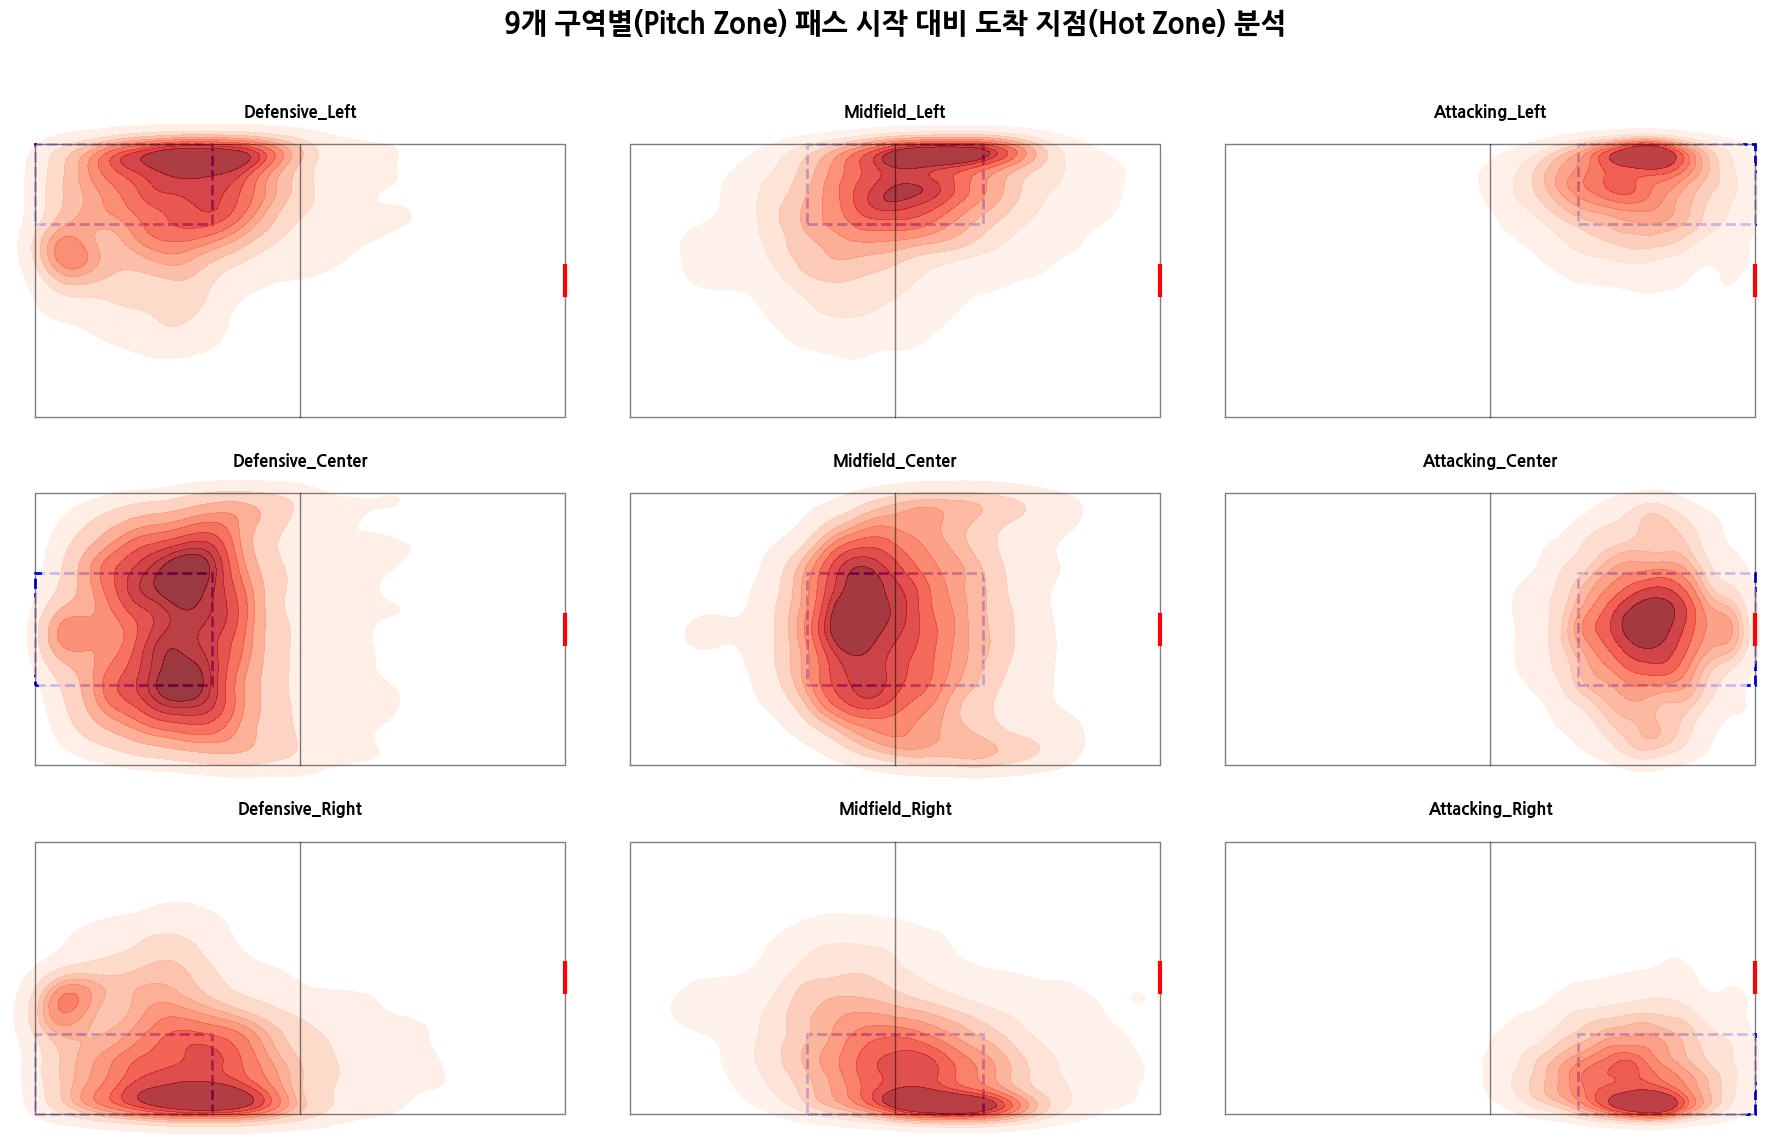

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches

# 패스 데이터만 필터링
pass_df = df_model[df_model['type_name'] == 'Pass'].copy()

# 3x3 격자 생성 (축구장 방향에 맞춰 가로를 넓게 설정)
fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharex=True, sharey=True)
fig.suptitle('9개 구역별(Pitch Zone) 패스 시작 대비 도착 지점(Hot Zone) 분석', fontsize=20, fontweight='bold')

# 3x3 격자에 들어갈 구역 이름 배열 (실제 축구장 방향 기준)
# Y축(행): Left(위), Center(중간), Right(아래)
# X축(열): Defensive(왼쪽), Midfield(중간), Attacking(오른쪽)
zone_matrix = [
    ['Defensive_Left', 'Midfield_Left', 'Attacking_Left'],
    ['Defensive_Center', 'Midfield_Center', 'Attacking_Center'],
    ['Defensive_Right', 'Midfield_Right', 'Attacking_Right']
]

# 구역별 X, Y 좌표 범위 (파란색 시작 박스를 그리기 위함)
x_ranges = [(0, 35), (35, 70), (70, 105)] # Defensive, Midfield, Attacking
y_ranges = [(48, 68), (20, 48), (0, 20)]  # Left, Center, Right (위에서 아래로)

# 3x3 반복문으로 9개의 경기장 미니맵 그리기
for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        zone_name = zone_matrix[i][j]

        # 현재 구역의 데이터만 필터링
        zone_data = pass_df[pass_df['pitch_zone'] == zone_name]

        # 1. 경기장 외곽선 및 중앙선 뼈대 그리기
        ax.plot([0, 105, 105, 0, 0], [0, 0, 68, 68, 0], color='black', linewidth=1, alpha=0.5)
        ax.plot([52.5, 52.5], [0, 68], color='black', linewidth=1, alpha=0.5)
        ax.plot([105, 105], [30.34, 37.66], color='red', linewidth=3) # 상대 골대

        # 2. 패스 시작 구역(Start Zone)을 파란색 점선으로 표시
        x_min, x_max = x_ranges[j]
        y_min, y_max = y_ranges[i]
        start_box = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                                      linewidth=2, edgecolor='blue', facecolor='none', linestyle='--')
        ax.add_patch(start_box)

        # 3. 도착 좌표(end_x, end_y) 히트맵 그리기
        if len(zone_data) > 10: # 노이즈 방지를 위해 데이터가 충분할 때만 그림
            sns.kdeplot(x=zone_data['end_x'], y=zone_data['end_y'], ax=ax,
                        fill=True, cmap='Reds', alpha=0.8, thresh=0.05)

        # 서브플롯 설정
        ax.set_title(zone_name, fontsize=12, fontweight='bold')
        ax.set_xlim(-5, 110)
        ax.set_ylim(-5, 73)
        ax.axis('off') # 깔끔하게 보이도록 축 좌표 숫자 제거

# 레이아웃 간격 조정
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 파생 변수 3: 최후방 빌드업 여부 (`is_gk_zone`)
* **아이디어:** 골키퍼나 최후방 수비수가 페널티 박스 안에서 차는 롱킥/클리어링은 일반적인 패스에 비해 도착 좌표의 분산(예측 오차)이 매우 큽니다.
* **구현:** `start_x`가 16.5(페널티 박스 라인) 이하이고, `start_y`가 골대 중앙 부근(13.84 ~ 54.16)인 경우를 1(True), 아니면 0(False)으로 라벨링하여 모델에게 불확실성이 높은 액션임을 명시적으로 알려줍니다.

### 파생 변수 4: 팀별 측면 공격 의존도 (`team_wing_ratio`)
* **아이디어:** 팀(`team_id`)마다 중앙을 고집하는 팀(티키타카)이 있고, 측면 크로스를 선호하는 팀이 있습니다. 팀별 고유 전술 패턴을 수치화합니다.
* **구현:** 각 팀의 전체 이벤트 중 측면 구역(Left, Right)에서 발생한 비율을 집계(Aggregation)하여 새로운 피처로 매핑합니다.

In [24]:
# ----------------------------------------------------
# 파생 변수 3: 최후방 빌드업(GK Zone) 여부
# ----------------------------------------------------
# 우리 팀 페널티 박스(X: 0~16.5, Y: 13.84~54.16)에서 발생한 액션인지 확인
is_in_penalty_box = (df_model['start_x'] <= 16.5) & \
                    (df_model['start_y'] >= 13.84) & \
                    (df_model['start_y'] <= 54.16)

df_model['is_gk_zone'] = is_in_penalty_box.astype(int)


# ----------------------------------------------------
# 파생 변수 4: 팀별 측면 공격 의존도 (Aggregation Feature)
# ----------------------------------------------------
# 1. 해당 액션이 측면(Left 또는 Right)에서 일어났는지 확인 (1 or 0)
df_model['is_wing_action'] = df_model['pitch_zone'].str.contains('Left|Right').astype(int)

# 2. 팀별로 '측면 액션의 비율'을 계산 (groupby -> mean)
# 예: A팀은 측면 액션 비율이 0.65 (65%), B팀은 0.40 (40%)
team_wing_ratio_dict = df_model.groupby('team_id')['is_wing_action'].mean().to_dict()

# 3. 계산된 비율을 원래 데이터프레임의 각 행에 매핑하여 새로운 변수 생성
df_model['team_wing_ratio'] = df_model['team_id'].map(team_wing_ratio_dict)


# ----------------------------------------------------
# 결과 확인
# ----------------------------------------------------
print("--- 1. 최후방 빌드업 (GK Zone) 데이터 샘플 ---")
display(df_model[df_model['is_gk_zone'] == 1][['type_name', 'start_x', 'start_y', 'is_gk_zone']].head(3))

print("\n--- 2. 팀별 측면 의존도 (team_wing_ratio) 상위 3팀 vs 하위 3팀 ---")
# 팀별 고유 비율 확인을 위한 요약
team_style_summary = df_model.groupby('team_id')['team_wing_ratio'].first().sort_values(ascending=False)

print("[측면 공격 선호 팀 (Top 3)]")
print(team_style_summary.head(3))
print("\n[중앙 공격 선호 팀 (Bottom 3)]")
print(team_style_summary.tail(3))

--- 1. 최후방 빌드업 (GK Zone) 데이터 샘플 ---


,type_name,start_x,start_y,is_gk_zone
22,Pass,10.287911,47.348944,1
33,Pass,15.575280,32.055404,1
34,Pass,2.823166,38.836840,1



--- 2. 팀별 측면 의존도 (team_wing_ratio) 상위 3팀 vs 하위 3팀 ---
[측면 공격 선호 팀 (Top 3)]
team_id
4643    0.605756
4644    0.603988
4641    0.603917
Name: team_wing_ratio, dtype: float64

[중앙 공격 선호 팀 (Bottom 3)]
team_id
316     0.582851
4639    0.581806
4648    0.555338
Name: team_wing_ratio, dtype: float64


### 📊 파생 변수 시각화 검증: 최후방 빌드업 및 팀별 전술 성향

새롭게 생성한 두 가지 고급 피처가 타겟 변수 예측에 어떻게 기여하는지 시각적으로 증명합니다.

1. **최후방 빌드업(`is_gk_zone`) 검증:** 최후방에서 시작된 패스(`is_gk_zone=1`)와 일반 지역 패스(`is_gk_zone=0`)의 **도착 X좌표(`end_x`) 분포**를 비교합니다. 골키퍼 롱킥의 높은 불확실성(넓은 분산)을 모델이 분리해서 학습할 수 있음을 보여줍니다.
2. **팀별 측면 의존도(`team_wing_ratio`) 검증:** 팀마다 중앙과 측면을 활용하는 비율이 어떻게 다른지 바 차트(Bar Chart)로 비교하여, 팀 ID(`team_id`)가 단순한 식별자가 아닌 '전술적 힌트'로 작용함을 보여줍니다.

/tmp/ipykernel_286/2381341756.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=pass_df, x='is_gk_zone', y='end_x', ax=axes[0], palette='pastel', inner='quartile')
/tmp/ipykernel_286/2381341756.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=team_ratio_df, x='team_id', y='team_wing_ratio', ax=axes[1], palette='coolwarm')


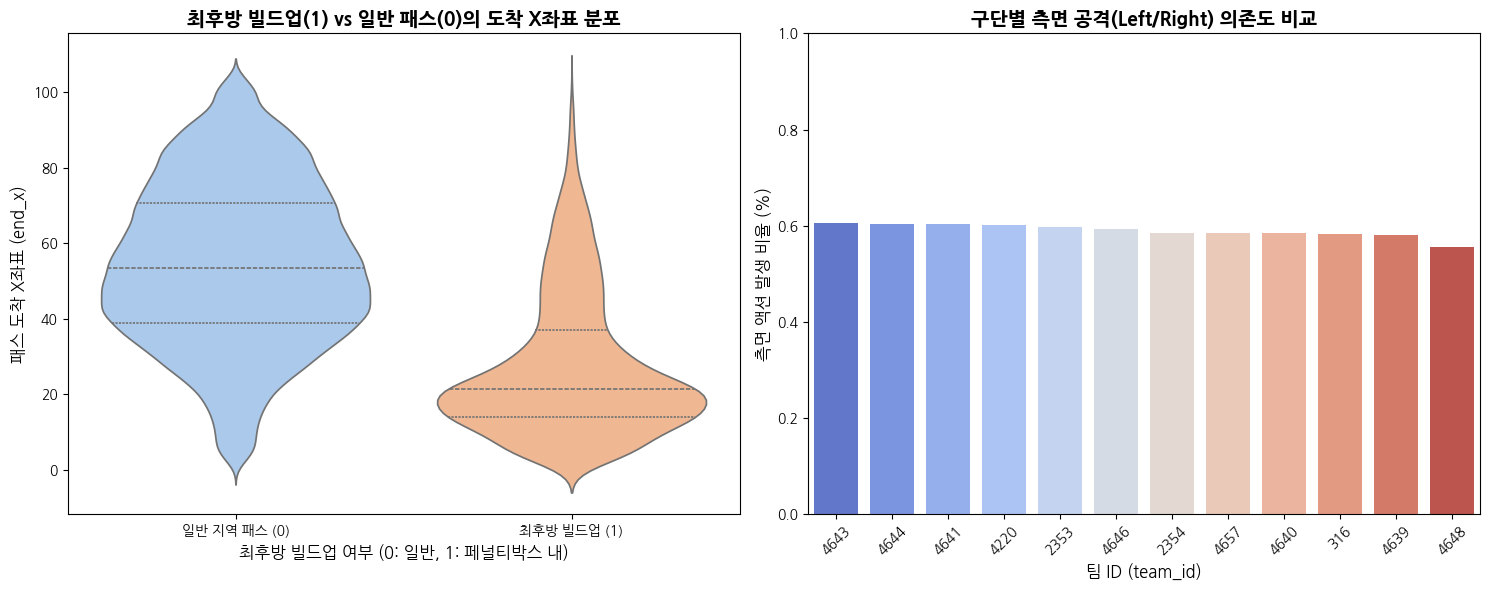

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# 패스(Pass) 데이터만 추출하여 공정한 비교 진행
pass_df = df_model[df_model['type_name'] == 'Pass'].copy()

# 그래프 세팅 (1행 2열로 두 개의 그래프를 나란히 배치)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ----------------------------------------------------
# 1. 최후방 빌드업 여부(is_gk_zone)에 따른 도착 X좌표 분포 (Violin Plot)
# ----------------------------------------------------
# 바이올린 플롯은 데이터의 밀도(분포)와 박스플롯(통계값)을 동시에 보여주어 분산 비교에 탁월합니다.
sns.violinplot(data=pass_df, x='is_gk_zone', y='end_x', ax=axes[0], palette='pastel', inner='quartile')

axes[0].set_title('최후방 빌드업(1) vs 일반 패스(0)의 도착 X좌표 분포', fontsize=14, fontweight='bold')
axes[0].set_xlabel('최후방 빌드업 여부 (0: 일반, 1: 페널티박스 내)', fontsize=12)
axes[0].set_ylabel('패스 도착 X좌표 (end_x)', fontsize=12)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['일반 지역 패스 (0)', '최후방 빌드업 (1)'])

# ----------------------------------------------------
# 2. 팀별 측면 의존도 (team_wing_ratio) 비교 (Bar Chart)
# ----------------------------------------------------
# 팀별 측면 비율 데이터를 추출하고 비율이 높은 순서대로 정렬
team_ratio_df = df_model.groupby('team_id')['team_wing_ratio'].first().sort_values(ascending=False).reset_index()

# 팀 ID를 범주형(문자열)으로 변환하여 X축에 깔끔하게 출력
team_ratio_df['team_id'] = team_ratio_df['team_id'].astype(str)

sns.barplot(data=team_ratio_df, x='team_id', y='team_wing_ratio', ax=axes[1], palette='coolwarm')

axes[1].set_title('구단별 측면 공격(Left/Right) 의존도 비교', fontsize=14, fontweight='bold')
axes[1].set_xlabel('팀 ID (team_id)', fontsize=12)
axes[1].set_ylabel('측면 액션 발생 비율 (%)', fontsize=12)

# Y축을 0~1 비율로 직관적으로 보이게 설정
axes[1].set_ylim(0, 1)
# X축 팀 이름이 겹치지 않게 회전
axes[1].tick_params(axis='x', rotation=45)

# 전체 레이아웃 깔끔하게 조정
plt.tight_layout()
plt.show()